# Notebook 04 — Geração de Isócronas (Áreas de Abrangência das UBS)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA  
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI  
**Autor:** Felipe Ramos Dantas  
**Orientador:** Prof. Dr. Antonio Joaquim da Silva  
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais  
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs  
**Última atualização:** 2026-06-22  

---
## Objetivo
Delimitar, para cada UBS, as **áreas de abrangência** (isócronas) de 10, 20 e 30 minutos,
nos modos **automóvel** e **pedestre**, usando o grafo de impedâncias do NB 03. As
isócronas, em formato de **anéis** (faixas de decaimento), alimentam o cálculo AE2SFCA
(NB 05).

## Entrada
| Arquivo | Origem |
|---|---|
| `intermediarios/04_impedancias/zonaUrbana_5km_road_routed.parquet` | NB 03 |
| `externos/pmt/ubs_zonaUrbana.geojson` | NB 01.3 (UBS) |

## Saída
| Arquivo | Consumido por |
|---|---|
| `intermediarios/05_isocronas/zonaUrbana_5km_isocronas_carro.parquet` | NB 05 |
| `intermediarios/05_isocronas/zonaUrbana_5km_isocronas_pedestre.parquet` | NB 05 |
| `outputs/tabelas/nb041/nb041_cobertura_isocronas.csv` | Resultados (5.4) |

## Pré-requisitos
- NB 03 executado. **Tempo de execução: ~20–25 min** (75 UBS × 2 modos).
---

In [12]:
# ── 1. IMPORTAÇÕES E CONFIGURAÇÃO ───────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


import city2graph.utils as c2g_utils
import city2graph.morphology as c2g_morpho

from mapeprof.config import (INT_IMPEDANCIAS, INT_ISOCRONAS, INT_UBS, EXT_IBGE,
                             FIGURAS, TABELAS, CRS_METRICO, criar_diretorios)
from mapeprof.viz import (aplicar_estilo, barra_escala, seta_norte, moldura_mapa,
                          formatar_eixos_mapa, ajustar_zoom_camada)

aplicar_estilo()
warnings.filterwarnings("ignore")
criar_diretorios()

FIGURAS_NB = FIGURAS / "nb041"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)
TABELAS_NB = TABELAS / "nb041"; TABELAS_NB.mkdir(parents=True, exist_ok=True)
print("✅ Setup concluído.")

✅ Setup concluído.


## 2. Carga dos dados

Carregamos o grafo de impedâncias (NB 03), as 75 UBS (oferta) e os limites territoriais
(moldura cartográfica). As UBS são identificadas pelo código CNES.

In [6]:
# ── 2. CARGA DOS DADOS ──────────────────────────────────────────────────────
roads = gpd.read_parquet(INT_IMPEDANCIAS / "zonaUrbana_5km_road_routed.parquet")
ubs = gpd.read_parquet(INT_UBS / "teresina_zonaUrbana_buffer5km_ubs_capacidade.parquet").to_crs(CRS_METRICO)
zona_urbana = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)
area_estudo = gpd.read_parquet(EXT_IBGE/ "teresina_zonaUrbana_buffer5kClip_utm.parquet").to_crs(CRS_METRICO)
print(f"🔄 {len(roads):,} arestas | {len(ubs)} UBS")

🔄 52,431 arestas | 81 UBS


## 3. Grafo de roteamento por modo

Cada modo percorre uma sub-rede distinta: o automóvel não trafega em calçadas/trilhas e
o pedestre não percorre vias expressas. No NB 03, essas combinações receberam impedância
**infinita**. Aqui, construímos **um grafo por modo** descartando as arestas de tempo
infinito — assim o roteamento opera apenas sobre a malha efetivamente percorrível.

In [7]:
# ── 3. GRAFO DE ROTEAMENTO POR MODO ─────────────────────────────────────────
def construir_grafo(col_tempo):
    """Constrói nós/arestas (city2graph) só com as arestas de tempo finito do modo."""
    sub = roads[np.isfinite(roads[col_tempo])].copy()
    nodes, edges = c2g_morpho.segments_to_graph(sub, multigraph=True, as_nx=False)
    return nodes, edges

nodes_carro, edges_carro = construir_grafo("tempo_carro_min")
nodes_pe,    edges_pe    = construir_grafo("tempo_pe_min")
print(f"🚗 grafo carro: {len(nodes_carro):,} nós | 🚶 grafo pé: {len(nodes_pe):,} nós")

Removed 32 invalid geometries
Removed 34 invalid geometries


🚗 grafo carro: 33,808 nós | 🚶 grafo pé: 34,660 nós


## 4. Parâmetros e geração das isócronas

- **Limiares**: 10, 20 e 30 minutos (faixas de decaimento do AE2SFCA).
- **Custo de terminal** (Campanelli *et al.*, 2026): subtraem-se **4 minutos** do orçamento
  (manobra, estacionamento e caminhada final até a recepção). Assim, a isócrona nominal de
  30 min percorre a malha por 26 min efetivos (6/16/26).
- **Método**: *concave hull* (variante alpha, `hull_ratio=0.15`), que contorna os nós
  alcançados sem englobar quarteirões sem via — evitando a superestimação do *convex hull*.
- **Anéis**: cada faixa é o polígono do limiar menos o do limiar anterior (diferença
  geométrica), evitando dupla contagem da demanda no NB 05.

In [8]:
# ── 4. FUNÇÃO DE GERAÇÃO DE ISÓCRONAS (EM ANÉIS) ────────────────────────────
LIMIARES_NOMINAIS = [10, 20, 30]
CUSTO_TERMINAL_CARRO = 4   # estacionar + caminhar até a recepção (específico do automóvel)
CUSTO_TERMINAL_PE    = 0   # pedestre chega direto à porta; sem custo de terminal

def gerar_isocronas(nodes, edges, edge_attr, modo, custo_terminal):
    limiares_efetivos = [t - custo_terminal for t in LIMIARES_NOMINAIS]
    saidas = []
    for _, u in tqdm(ubs.iterrows(), total=len(ubs), desc=f"Isócronas ({modo})"):
        uid = u.get("cnes", u.name)
        try:
            iso = c2g_utils.create_isochrone(
                nodes=nodes, edges=edges, center_point=u.geometry,
                threshold=limiares_efetivos, edge_attr=edge_attr,
                method="concave_hull_alpha", hull_ratio=0.15, allow_holes=False,
            ).sort_values("threshold").reset_index(drop=True)
            aneis, anterior = [], None
            for _, r in iso.iterrows():
                aneis.append(r.geometry.difference(anterior) if anterior is not None else r.geometry)
                anterior = r.geometry
            iso["geometry"] = aneis
            iso["threshold_nominal"] = iso["threshold"] + custo_terminal
            iso["ubs_id"] = uid; iso["modo"] = modo
            saidas.append(iso)
        except Exception as e:
            print(f"⚠️ UBS {uid} falhou: {str(e)[:60]}")
    return gpd.GeoDataFrame(pd.concat(saidas, ignore_index=True), geometry="geometry", crs=CRS_METRICO)

# ── 5. GERAÇÃO E EXPORTAÇÃO ──────────────────────────────────────────────────
isocronas_carro = gerar_isocronas(nodes_carro, edges_carro, "tempo_carro_min", "carro", CUSTO_TERMINAL_CARRO)
isocronas_pe    = gerar_isocronas(nodes_pe,    edges_pe,    "tempo_pe_min",    "pedestre", CUSTO_TERMINAL_PE)

Isócronas (pedestre): 100%|██████████| 81/81 [06:29<00:00,  4.80s/it]


## 5. Execução e exportação

⏳ Esta etapa leva ~20–25 minutos (75 UBS × 2 modos). Execute uma vez e reutilize os
arquivos salvos.

In [9]:
isocronas_carro.to_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_carro.parquet")
isocronas_pe.to_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_pedestre.parquet")
print(f"💾 Carro: {len(isocronas_carro)} anéis | Pé: {len(isocronas_pe)} anéis")

💾 Carro: 243 anéis | Pé: 243 anéis


In [10]:
# ── Fig. 01/02 — Isócronas por modo (todas as UBS) ──────────────────────────
CORES_FAIXA  = {10: "#A50026", 20: "#F46D43", 30: "#FEE08B"}      # núcleo → periferia
ROTULO_FAIXA = {10: "0–10 min", 20: "10–20 min", 30: "20–30 min"}  # anéis exclusivos

def mapa_isocronas(iso, fonte, arquivo):
    fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")
    area_estudo.boundary.plot(ax=ax, color="#777777", ls=":", lw=0.8, zorder=1)
    for limiar in (30, 20, 10):                                   # maior por baixo
        faixa = iso[iso["threshold_nominal"] == limiar]
        if not faixa.empty:
            faixa.plot(ax=ax, color=CORES_FAIXA[limiar], alpha=0.75, linewidth=0, zorder=2)
    zona_urbana.boundary.plot(ax=ax, color="black", ls="--", lw=0.9, zorder=3)
    ubs.plot(ax=ax, color="#08306B", markersize=9, edgecolor="white", linewidth=0.4, zorder=5)
    ax.legend(handles=[
        Patch(facecolor=CORES_FAIXA[10], label=ROTULO_FAIXA[10]),
        Patch(facecolor=CORES_FAIXA[20], label=ROTULO_FAIXA[20]),
        Patch(facecolor=CORES_FAIXA[30], label=ROTULO_FAIXA[30]),
        Line2D([], [], marker="o", color="#08306B", markeredgecolor="white",
               lw=0, markersize=6, label="UBS"),
        Line2D([], [], color="black",  ls="--", lw=1, label="Zona urbana"),
        Line2D([], [], color="#777777", ls=":", lw=1, label="Área de estudo (5 km)"),
    ], loc="lower right", title="Tempo de viagem", fontsize=6, title_fontsize=7,
       labelspacing=0.25, framealpha=0.85)
    ajustar_zoom_camada(ax, area_estudo, margem=0.02)   # zoom no buffer (padrão dos mapas de rede)
    moldura_mapa(ax, "", fonte)
    formatar_eixos_mapa(ax, fontsize=5)
    barra_escala(ax); seta_norte(ax)
    fig.savefig(FIGURAS_NB / arquivo, dpi=300, bbox_inches="tight")
    plt.show()

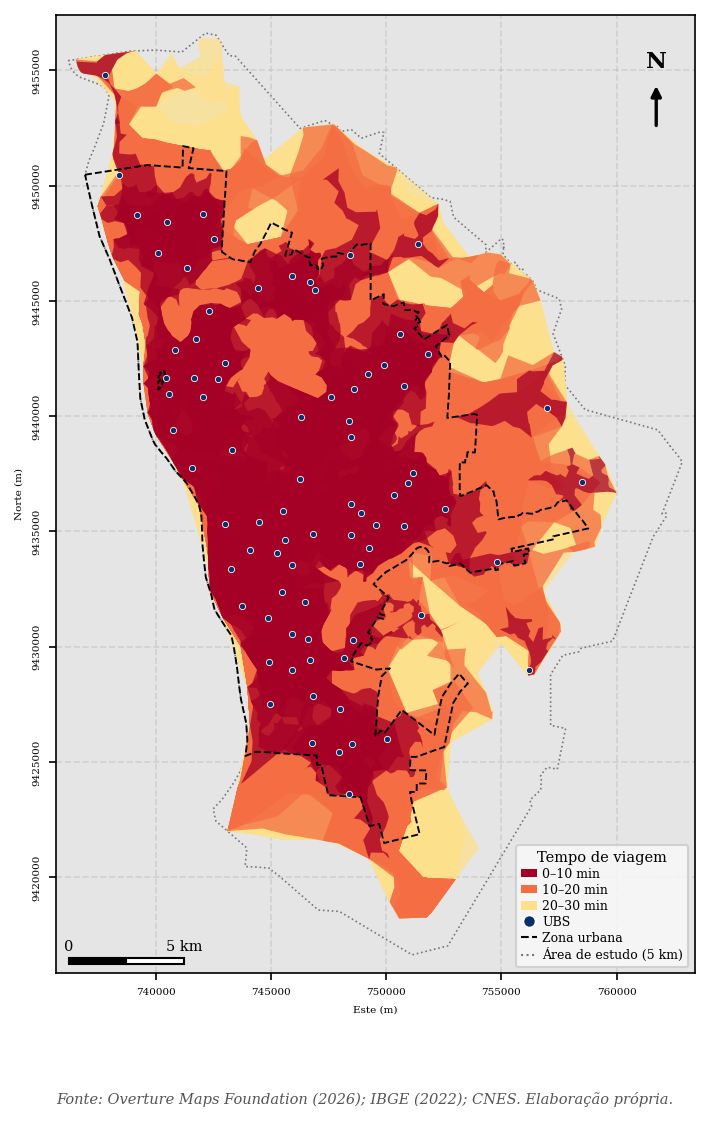

In [13]:
# Célula 7 — Figura 21 (automóvel)
mapa_isocronas(isocronas_carro,
               "Overture Maps Foundation (2026); IBGE (2022); CNES. Elaboração própria.",
               "nb041_fig01_isocronas_carro.png")

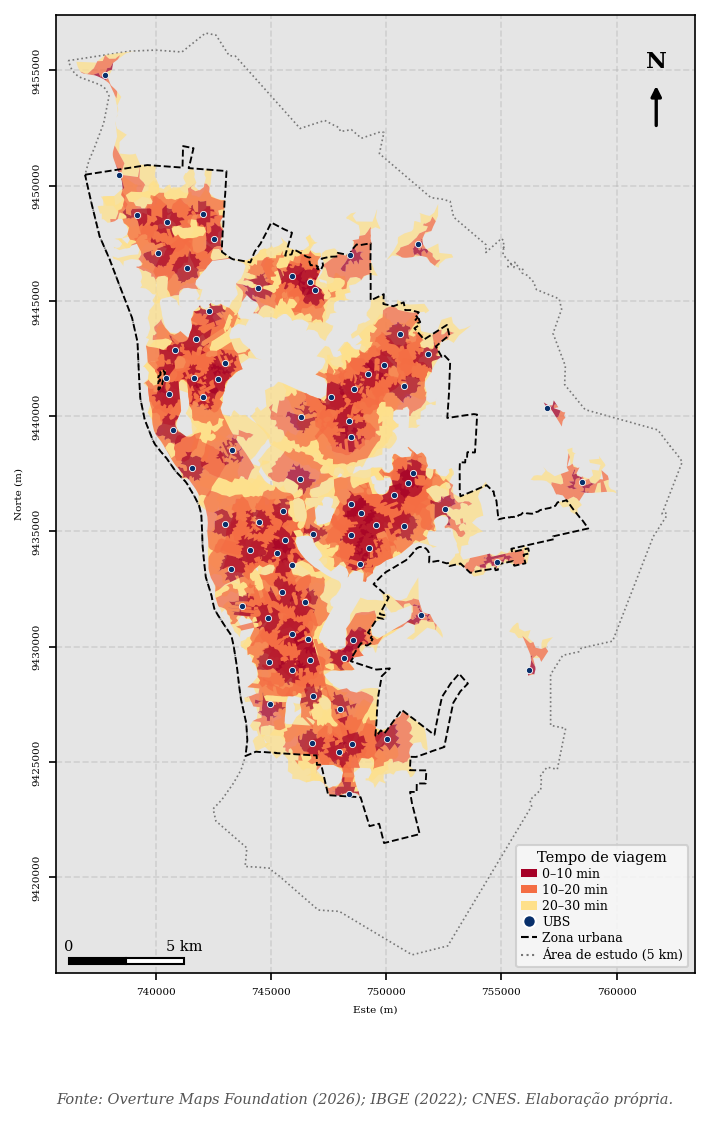

In [14]:
# Célula 8 — Figura 22 (pedestre)
mapa_isocronas(isocronas_pe,
               "Overture Maps Foundation (2026); IBGE (2022); CNES. Elaboração própria.",
               "nb041_fig02_isocronas_pedestre.png")

 limiar_min  cobertura_carro_pct  cobertura_pe_pct
         10                 75.6              18.0
         20                 97.1              51.1
         30                 98.5              69.5


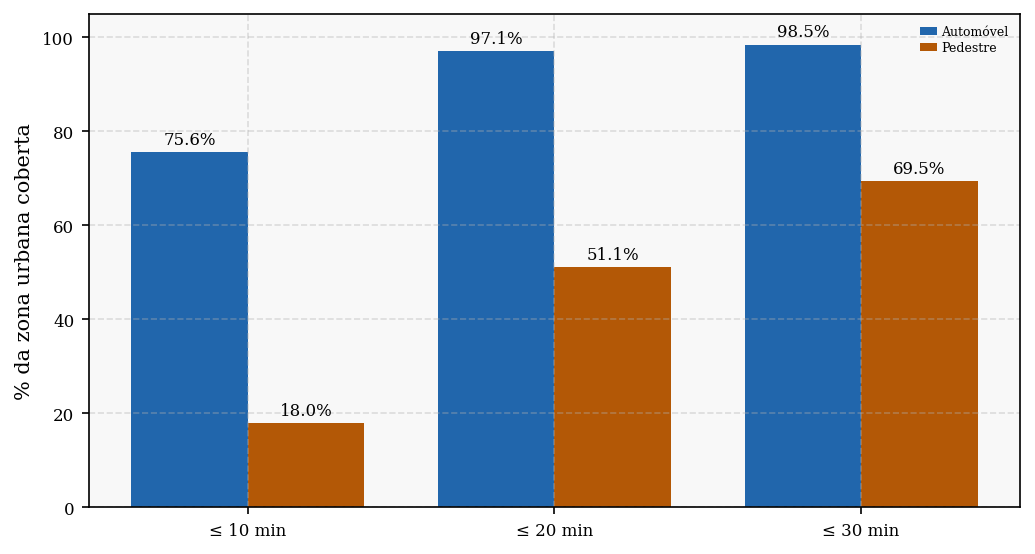

In [16]:
# ── Fig. 03 + Tabela — Cobertura da Zona Urbana por tempo de viagem ─────────
# Proporção (%) da ZU alcançável (CUMULATIVA) até cada limiar, por modo.
area_zu = zona_urbana.area.sum()

def cobertura(iso):
    out = {}
    for limiar in LIMIARES_NOMINAIS:
        uniao = iso[iso["threshold_nominal"] <= limiar].union_all()
        coberta = gpd.GeoSeries([uniao], crs=CRS_METRICO).clip(zona_urbana).area.sum()
        out[limiar] = coberta / area_zu * 100
    return out

cob_carro, cob_pe = cobertura(isocronas_carro), cobertura(isocronas_pe)

# dict -> DataFrame (é o DataFrame que tem .to_csv, não o dict)
tab_cob = pd.DataFrame({
    "limiar_min":          LIMIARES_NOMINAIS,
    "cobertura_carro_pct": [round(cob_carro[l], 1) for l in LIMIARES_NOMINAIS],
    "cobertura_pe_pct":    [round(cob_pe[l], 1)    for l in LIMIARES_NOMINAIS],
})
tab_cob.to_csv(TABELAS_NB / "nb041_cobertura_isocronas.csv",
               sep=";", index=False, encoding="utf-8-sig")
print(tab_cob.to_string(index=False))

# Gráfico de barras
x = np.arange(len(LIMIARES_NOMINAIS)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 3.8))
b1 = ax.bar(x - w/2, tab_cob["cobertura_carro_pct"], w, label="Automóvel", color="#2166AC")
b2 = ax.bar(x + w/2, tab_cob["cobertura_pe_pct"],    w, label="Pedestre",  color="#B35806")
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"≤ {l} min" for l in LIMIARES_NOMINAIS])
ax.set_ylabel("% da zona urbana coberta"); ax.set_ylim(0, 105); ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb041_fig03_cobertura.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Próximos passos
O **NB 05** cruzará estes anéis com a população (areal) dos setores censitários, aplicando
os pesos de decaimento do AE2SFCA (1,00 / 0,68 / 0,22) para calcular o índice de
acessibilidade e identificar os "desertos de saúde".